In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[2] if "__file__" in dir() else Path.cwd().parents[1]
RAW_DIR = REPO_ROOT / "data" / "raw" / "injep"
PROCESSED_DIR = REPO_ROOT / "data" / "processed" 
MASTER_CSV = REPO_ROOT / "data" / "processed" / "big5_participation_master.csv"

# Football participation data in the Top 5 European Leagues

## Introduction

Answering a question with data can be frustrating if you know and care about the data. The scientific approach relies on constructive doubts, margin of errors, honesty and trust. The building block of a serious data analysis is the measure and how we take it and evaluate its precision, influence the answers to question we may ask about a certain task or reality. In the latest years, I am convinced that a further layer of complexity has been added and it is communication. How we communicate results to an audience is important (and that's why I mentioned honesty and trust) as the way results are presented is itself part of the results. Often, a data scientist communicate a likely outcome and most of the audience hear "a fact". 

A question like "How popular is football in different countries" can be seen within different perspective also on the ground of the available data you have or can retrieve. Defining measures is the core of science and the starting point of any scientific analysis and discussion. You can measure popularity in different ways, but if you want to make comparisons, the measure itself must be the same for each different component, in our case the country, you want to compare. 

In this notebook, I will go through the process of collecting and processing data with the aim of measuring the Football participation data for the five major european football federations in Europe, namely England FA (not UK), Germany DFB, Spain, France FFF and Italy FIGC. Ironically, that the fact I am stating that these are the top 5 leauges in Europe would require a justification based on data, so I should first collect and process data to strenght my statement but, as we will see, collecting data is a time and resources consuming task so, at this stage, it is fine I am stating that *these* are the top five countries. Otherwise, I can just say "the hell with that. I am interested in these countries and if you're not OK with this, collect data by yourself". 

#

## Football: The Quest for Data 

When I was a kid, I was a fan of the old Superman movies, the ones starring Christopher Reeve. The fourth, and last one, was titled [Superman IV: The Quest for Peace](https://en.wikipedia.org/wiki/Superman_IV%3A_The_Quest_for_Peace) and its outcome was so disastrous that the franchise was put on hold for the next 19 years. If you ask me, the [reboot](https://en.wikipedia.org/wiki/Superman_Returns) was not at the same level as the ones I saw during my childhood, it might be a sense of nostalgia or, as I am ready to die for it, a manifest superiority of the joy, campiness and craft of the Reeves (and Margot Kidder, and Gene Hackman - I mean, GENE HACKMAN) movies. As I said, the movie was a disaster: the plot scrambled, the poor budget impacted the supposed "grandiose" mis an scene with ridicoulus solutions, the confused production reflected in every different aspect of the final outcome. Still today, it is considered [one of the worst movie ever made](https://www.empireonline.com/movies/features/50-worst-movies-ever-2/#40-superman-iv-the-quest-for-peace).

So, when "questing for data", we have to take into account that if not done properly, it will impact the final analysis in the same, disastrous way and our franchise will be closed for the next 20 years. And a lot of things can go wrong when searching and storing data, especially if you are looking for open data, i.e. data often collected and curated  by different people and organization with scopes that differ from yours. When trying to respond the the question "How Popular is Football in the top 5 countries", different aspect can reflect popularity, one, for sure, is how many people are currently playing football for each country. The measure "how many people play football" itself can be built in different ways and as we are not the ones "building the measure", we must rely on metrics defined by others and available for free - nothing is "for free" really as it might take a long time collecting what you need. AI tools (I am using Claude and Claude Code in this project) are incredibly useful but they must be used with care as they still did not reached (yet?) the level of accurancy a truly analysis require. Machines can make less mistakes of human being, especially in repetive tasks, but still they are not perfect. AI systems are built on our past and previous knowledge that is often far from correct, so it's not realistic, at this stage, expecting a perfect output autonomously from their use. We, as human beings, are still usefull. Maybe less, but yet we can make a positive contribution, don't let us down!


If we want to answer the question "how many people play football", our first task is to look for data that would measure the "participation" in this sport in these countries. As we will see in this article, there can be different way to build this measure: one is asking (survey) if people play football or not, the other one is counting (retrieving membership numbers). For both way, then, we can try to collect breakdown in terms of gender and age and this granularity will give a larger picture about "how many people play football" in terms of different slices of each country society. But who is collecting this data and how can I trust the source? Ideally, when collecting data you look for different, independent sources and check they all give the same (or homogeneous) results. In practice, not always this is possible and sometimes you realize that even if you find a different source, this latter relies on the first one and so you lose the "indipendence" of the source. When you are aware of this problem, the best solution is to be honest and flag it as a "limitation", "known issue", "caveat" of your findings. Let me emphasize that this should also be reflected when presenting findings and this can harm the communication. In this article we are talking about football data and there is nothing really harmful or shameful in showing carefulness when presenting results. If I state "with this data, that have their limitation, we can see that probably" and convey ideas of margin of errors, doubts and similar feelings, there is nothing wrong and the audience is not really bothered about this - a part, maybe, the tiredeness of listening to someone overly cautios that always seems to excuse themselves making a longer speak without going straight to the point. But in other situations regarding, for example, economic or public health data, in which the same care and cautiousness should be communicated to the audience, this can weakened the conversation. We are more incline to listen to people carrying on a self-ensuring image of themselves and the work they've done. We automatically think that if someone shows you something that is certain using data, the amount and quality of work and effort put for getting the result is strong and believable. If, after so many hours spent in a research project (in every field, economics, healthcare, science), you go to a generic audience and say "well, the data, collected using these samples suggests that this plan is effective with this margin of error" you will not achieve the same results as someone saying "the data show that **this** plan will work". And yet, I think that showing difficulties and limitations, in the long run, is more effective that giving certainties that real scientific studies never give. In this way, I am convinced that people will put their trust more on scientific, data based conclusions with respect to less informed analysis. Finally, the choice to who believe and why is up to you, but at least I made a try.

## Football participation data: Sources

The first places where to look for participation or membership data would obviously be the different Football association. I am not spending too much about explaining how governance in football works, but it is well known that the [Fédération Internationale de Football Association or FIFA](https://www.fifa.com/en) is the international governing association for all football in the world. And while FIFA is the worldwide governing body of football, continental confederations such as the [Union of European Football Associations (UEFA)](https://www.uefa.com/) operate under FIFA and manage football within their region. We than have the different national federations, like The England Football Association (FA), the Italian Football Federation (FIGC), French Football Federation (FFF), German Football Association (DFB) and Royal Spanish Football Federation (RFEF) are members of both FIFA and UEFA, and govern football domestically in their own countries. These federations collect and publish data about membership and participation and are the better sources where to search and collect data we need. 

In the context of our analysis, we will soon see that there is no standard way of collecting these data, as every national federation decide how to collect and share these data. Usually, all of them issue annual reports, often in their own language only, using different methodologies on how to collect and categorize the data (for example, what is considered young and senior membership) and their granularity (based on age, region, gender and so on). Also the format may differ, with some preferring sharing PDF files, other sharing data through a website. These different ways of collecting and sharing data, poses different challenges when we want to analyse and compare them. Some you can predict before hand, but sometimes they rise in the process of searching and boxing them.

The best way to show and explain these challenges, is to go through the journey and see what happens.

In the following sections, I will discuss different sources and how data could be collected and organised singularly and then evaluating how they could be represented in a single dataset in order to be compared. By the end of this process, we will have a snapshot of each federation as a standalone unit, and only then will we compare them with each other.

### FIFA and UEFA - supranational sources

A single data point fails to explain anything, although many people starts their conversation with a sentence like "this data explain..". To seriously infer insights from a data analysis project, you need to collect data for multiple measures. In our specific case, collecting data for a single year will give us a snapshot valid only for that specific points, with no clues if it is representative of the entire problem we want to tackle or a specific and different instance. Take as an example the years that COVID hit Europe: if you take the data for that year, you will be left with a very skewed picture that would explain nothing about a complex structure. So, when considering valid sources for our project, we will look for repositories containing different years and, hopefully, gathering data with the same or similar methodology.  

When I started collecting data, the first source I checked was, of course, FIFA as I thought the organization could and would store the data of number of athletes in the different country. But the situation was far from ideal: there is no known FIFA-maintained annual longitudinal dataset (e.g. every year for 10 years) publicly available with full football membership breakdowns by country, gender and age for the five federations you listed.

Fifa published two main reports for women football, one in [2019](https://digitalhub.fifa.com/m/231330ded0bf3120/original/nq3ensohyxpuxovcovj0-pdf.pdf) and the other one in [2023](`https://digitalhub.fifa.com/m/28ed34bd888832a8/original/FIFA-Women-s-Football-MA-Survey-Report-2023.pdf), directly produced by FIFA, while in [2014](https://www.icsspe.org/system/files/FIFA%20-%20Womens%20Football%20Survey.pdf) commissioned and publish a survey produced by ICSSPE, using data collected by FIFA via an online survey.

FIFA's public record on men's football are not better as only three documents exist.

The [Big Count 2006](https://digitalhub.fifa.com/m/55621f9fdc8ea7b4/original/mzid0qmguixkcmruvema-pdf.pdf) is the most recent FIFA survey to have published comprehensive country-level registration data for men. It was the second and last edition of a survey first run in 2000.

The [FIFA Professional Football Report 2023](https://digitalhub.fifa.com/m/28ed34bd888832a8/original/FIFA-Women-s-Football-MA-Survey-Report-2023.pdf)  covers men's professional players only — those holding written contracts at clubs. It gives country-level headcounts for the professional tier but says  nothing about the millions of registered amateur and youth players beneath it.

The [FIFA Professional Football Landscape](https://landscape.fifa.com)  launched in 2021 is an interactive database fed by member associations on an  ongoing basis. It reflects a current snapshot — no historical archive, no downloadable table, no time series.

UEFA documentation faces a similar limitation: its figures originate from self-reported data submitted by the national associations themselves, which means UEFA cannot independently verify the numbers it publishes

The only viable way to collect data left was directly going for the 5 federations.

## France Federation Data - INJEP

Each year, the **Institut National de la Jeunesse et de l'Éducation Populaire (INJEP)**, the French ministry body responsible for sport and youth statistics, publishes annual open-data files aggregating sport licence registrations reported by all recognised sports federations to the Ministry of Sport. 

Collecting this data was not as easy as expected as, although the data are open, the INJEP site blocked automated download and, as a workaround, I used the data.gouv.fr mirror, i.e. the French open government data portal, which hosts the same files without the restriction. At the end, the data were [manually downloaded from the corresponding page](https://www.data.gouv.fr/datasets/donnees-geocodees-issues-du-recensement-des-licences-et-clubs-aupres-des-federations-sportives-agreees-par-le-ministere-charge-des-sports). When you're dealing with a reasonable time span like 10 to 15 years, this is still a viable option if you don't want to spend too much time and efforts (and tokens) for doing it programmatically. I am sure skilled programmers are able to do it, but if your programming skills are more oriented on the data analysis, this can be a very frustrating and long exercise. I did it with a reasonable number of swearing and no one around to hear me, so no harm done. But it left me genuinely puzzled about how anyone fully reliant on generic AI tools could expect this to be straightforward. I tried using Claude and Claude Code to automate the download and with very poor results. I am still not sure what I did wrong, and I am equally sure there are marketing people somewhere who would tell me it is trivial. If you know the answer, you are on my heroes list permanently. 

Once the data were downloaded, I also found out the data encoding was a little bit different. For example, one year the column separator of the downloaded `.csv` file was a comma, others a semicolon"; or the encoding would change from `Latin-1` to `UTF-8`. At the end, this is a common and yet annoying issue when you are collecting data: different languages may use a characters sets which machines, or automated programs, treat differently and this can lead to mismatch when joining data from different years or sources. And usually you realize if only after spending a considerable amount of time digging into data. And only if you have a very meticulous and fussy mindset that prevents you from sweeping the dirt under the rug. That's funny, isn't it? No, it's not. I won't bother you describing all passages, just showing the different challenges you might find when your task is collecting data. 

Having said that, the data are at a very good level of granularity. Each file breaks down licences by municipality, sex, and age band, giving a much richer picture than a simple national total. The age breakdown in particular is worth noting: INJEP uses fine-grained bands (e.g. "5 à 9 ans", "10 à 14 ans", "15 à 19 ans") that allow us to distinguish between very young players, teenagers, and adults with reasonable precision. This granularity is not available in all five federations we analyse, which makes France one of the more informative sources in our dataset.

In [4]:
IN_CSV = REPO_ROOT / "inpat-expat" / "women-football" /"data" / "processed" / "injep_france_football_licences.csv"
df_french_data =pd.read_csv(IN_CSV)
print(df_french_data.shape)
df_french_data.columns

(270, 13)


Index(['country', 'season', 'gender', 'age_group', 'age_threshold',
       'registered_players', 'metric_name', 'source_name', 'source_url',
       'source_page', 'quality_flag', 'notes', 'year'],
      dtype='str')

In [5]:
print(df_french_data[df_french_data['registered_players'].isna()][
    ['season', 'gender', 'age_group', 'age_threshold']
].to_string(index=False))


Empty DataFrame
Columns: [season, gender, age_group, age_threshold]
Index: []


### Trends in French football licences, a gender comparison

The chart below shows the absolute number of FFF licences by gender from 2015 to 2023. The two series live on different scales: male licences are roughly an order of magnitude larger than female, so we use a dual y-axis to make both trends readable simultaneously. The 2020-21 season is shaded to mark the COVID disruption.

Before reading the trends, one caveat is worth stating clearly: a disruption like COVID does not just create a gap in the series but it potentially resets the baseline from which subsequent growth is measured. A post-disruption rebound can look like acceleration when it is partly recovery. Conversely, if participation never fully recovered, post-COVID trends underestimate the true underlying growth. With only two post-COVID data points available for France, we cannot yet distinguish between genuine structural acceleration and a rebound effect. We will carry this uncertainty forward throughout the analysis.


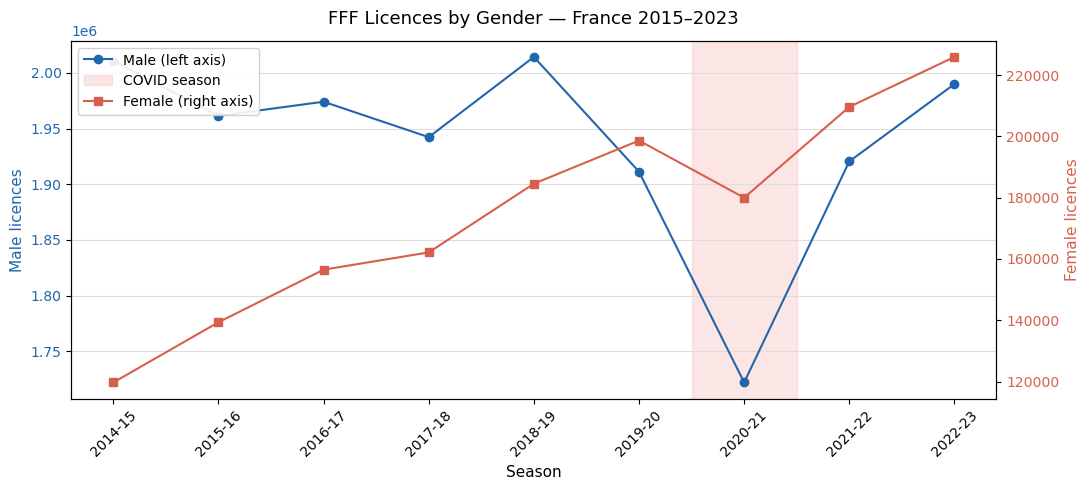

In [6]:
df_totals = df_french_data[df_french_data["age_group"] == "total"].copy()

COVID_SEASON = "2020-21"
seasons = sorted(df_totals["season"].unique())
covid_idx = seasons.index(COVID_SEASON)
x_pos = range(len(seasons))

df_male   = df_totals[df_totals["gender"] == "male"].sort_values("season")
df_female = df_totals[df_totals["gender"] == "female"].sort_values("season")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

color_male   = "#2166ac"
color_female = "#d6604d"

ax1.plot(list(x_pos), df_male["registered_players"].values,
         color=color_male, marker="o", label="Male (left axis)")
ax2.plot(list(x_pos), df_female["registered_players"].values,
         color=color_female, marker="s", label="Female (right axis)")

ax1.axvspan(covid_idx - 0.5, covid_idx + 0.5,
            color="lightcoral", alpha=0.2, label="COVID season")

ax1.set_ylabel("Male licences", color=color_male, fontsize=11)
ax2.set_ylabel("Female licences", color=color_female, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_male)
ax2.tick_params(axis="y", labelcolor=color_female)
ax1.set_xlabel("Season", fontsize=11)
ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(seasons, rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", framealpha=0.9)

ax1.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax2.yaxis.grid(False)
ax1.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.title("FFF Licences by Gender — France 2015–2023", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


The chart reveals two distinct patterns. Male licences are broadly flat over the period, with no sustained growth trend: the series oscillates around a stable level and the COVID disruption in 2020-21 was severe, with a recovery by 2022-23 that has not yet reached the pre-pandemic peak. Female licences, by contrast, show a consistent upward trajectory interrupted only briefly by COVID, with a strong recovery that by 2022-23 reaches the highest point in the series.

Two questions follow naturally from this picture. First, how steep is the female growth trend, and did it change after COVID? Second, how severe was the COVID shock for each gender, and what does the recovery pattern suggest about the underlying structural dynamics? We address both through two complementary approaches: a **segmented trend analysis** and an **interrupted time series model**.

### Route 1 — Segmented trend analysis


We fit separate linear trends for the pre-COVID period (2015 to 2019-20) and the post-COVID period (2021-22 to 2022-23), excluding the disrupted season (2020-21). The slope of each segment, expressed as additional licences per season, gives a direct measure of growth pace before and after the disruption. Comparing the two slopes tells us whether the trend accelerated, decelerated, or reversed after COVID.

Note that the post-COVID segment contains only two data points, which means the slope estimate carries high uncertainty. We report it for completeness but treat it as indicative rather than conclusive.

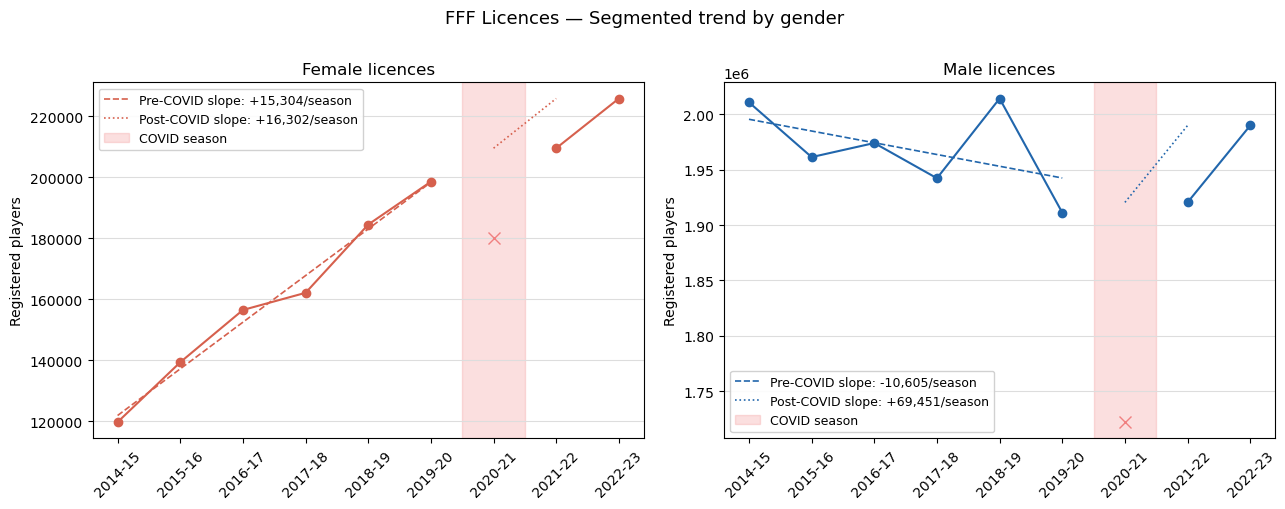

In [7]:
import numpy as np
from scipy import stats

PRE_COVID  = ["2014-15", "2015-16", "2016-17", "2017-18", "2018-19", "2019-20"]
POST_COVID = ["2021-22", "2022-23"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, gender, color in zip(axes, ["female", "male"], ["#d6604d", "#2166ac"]):
    df_g = df_totals[df_totals["gender"] == gender].sort_values("season")
    df_g = df_g.set_index("season")

    pre  = df_g.loc[PRE_COVID,  "registered_players"]
    post = df_g.loc[POST_COVID, "registered_players"]

    x_pre  = np.arange(len(pre))
    x_post = np.arange(len(pre), len(pre) + len(post))

    slope_pre,  intercept_pre,  *_ = stats.linregress(x_pre,  pre.values)
    slope_post, intercept_post, *_ = stats.linregress(x_post, post.values)

    x_all = np.arange(len(PRE_COVID) + 1 + len(POST_COVID))
    ax.plot(x_all[:len(PRE_COVID)],
            df_g.loc[PRE_COVID, "registered_players"].values,
            color=color, marker="o")
    ax.plot(x_all[len(PRE_COVID) + 1:],
            df_g.loc[POST_COVID, "registered_players"].values,
            color=color, marker="o")

    # trend lines
    ax.plot(x_pre,  intercept_pre  + slope_pre  * x_pre,
            color=color, linestyle="--", linewidth=1.2, label=f"Pre-COVID slope: {slope_pre:+,.0f}/season")
    ax.plot(x_post, intercept_post + slope_post * x_post,
            color=color, linestyle=":",  linewidth=1.2, label=f"Post-COVID slope: {slope_post:+,.0f}/season")

    # COVID gap
    covid_x = len(PRE_COVID)
    ax.axvspan(covid_x - 0.5, covid_x + 0.5, color="lightcoral", alpha=0.25, label="COVID season")
    ax.plot(covid_x, df_g.loc["2020-21", "registered_players"],
            color="lightcoral", marker="x", markersize=9, zorder=5)

    all_labels = PRE_COVID + ["2020-21"] + POST_COVID
    ax.set_xticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels, rotation=45)
    ax.set_title(f"{gender.capitalize()} licences", fontsize=12)
    ax.set_ylabel("Registered players")
    ax.legend(fontsize=9, framealpha=0.9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("FFF Licences — Segmented trend by gender", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the segmented trends tell us

**Female licences** show a remarkably stable growth trajectory. The pre-COVID slope of +15,304 licences per season is almost identical to the post-COVID slope of +16,302, with a difference of less than 7%. In other words, the COVID disruption barely altered the underlying female growth trend: the series dipped in 2020-21 and then resumed almost exactly where it would have been without the interruption. Whether this reflects structural resilience or a rebound effect inflating the post-COVID slope cannot be determined with only two post-COVID points and yet the consistency is striking.

**Male licences** tell a different story. The pre-COVID trend was already slightly negative (-10,605 licences per season), suggesting a slow but steady erosion of male participation before the pandemic even arrived. The post-COVID slope of +69,451 looks like strong recovery, but this figure is almost entirely driven by the distance between the COVID trough (2020-21) and the following two seasons meaning that it measures rebound, not a new structural trend. Male licences in 2022-23 have not yet returned to the pre-COVID peak of 2018-19.

Two findings are worth carrying forward into the cross-federation comparison. First, female football in France was growing steadily before COVID and continued growing afterwards at essentially the same pace and it looks like the COVID disruption was a pause, not a turning point. Second, male football was in gentle decline before COVID, and the apparent post-COVID recovery is likely a rebound rather than a reversal of that trend. Both conclusions are tentative given the limited post-COVID window, and we should revisit them when more, recent data becomes available.


### Route 2 — Interrupted time series (ITS)

A segmented trend fits two independent lines and compares their slopes. An [interrupted time series (ITS) model](https://en.wikipedia.org/wiki/Interrupted_time_series) goes one step further: it fits a single model that explicitly estimates both the **immediate level shift** caused by the disruption (did participation drop overnight?) and the **change in slope** after the disruption (did the growth rate change permanently?). This gives a more rigorous decomposition of the COVID effect.

The model takes the form:

$$Y_t = \beta_0 + \beta_1 \cdot t + \beta_2 \cdot D_t + \beta_3 \cdot (t - t^*) \cdot D_t + \varepsilon_t$$

where:
- $t$ is time (season index)
- $D_t = 1$ for all seasons after the disruption, $0$ before
- $\beta_1$ is the pre-COVID slope
- $\beta_2$ is the immediate level shift at the point of disruption
- $\beta_3$ is the change in slope after the disruption

A $\beta_3$ close to zero means the underlying trend was unchanged by COVID — the disruption was a temporary shock with no lasting structural effect. A large positive $\beta_3$ would suggest post-COVID acceleration; a negative one would suggest permanent damage.

We exclude the COVID season (2020-21) from the model as it represents the disruption itself rather than the underlying process.



ITS model — FEMALE
  Pre-COVID slope  (β1): +15,304 licences/season
  Level shift      (β2): -4,118 licences at disruption
  Slope change     (β3): +998 licences/season after COVID
  R²: 0.994
  N : 8 observations (COVID season excluded)

ITS model — MALE
  Pre-COVID slope  (β1): -10,605 licences/season
  Level shift      (β2): -11,405 licences at disruption
  Slope change     (β3): +80,056 licences/season after COVID
  R²: 0.439
  N : 8 observations (COVID season excluded)


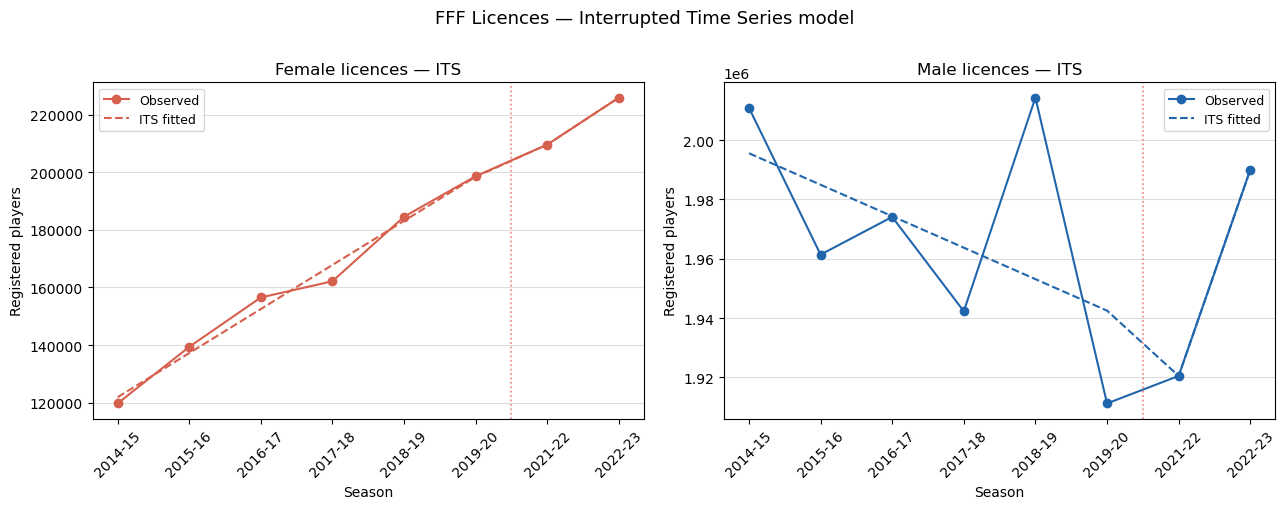

In [8]:
import statsmodels.api as sm

def run_its(df_g, gender):
    df_g = df_g[df_g["gender"] == gender].sort_values("season").copy()
    df_g = df_g[df_g["season"] != "2020-21"].reset_index(drop=True)
    df_g["t"] = range(len(df_g))
    cutpoint = df_g[df_g["season"] == "2021-22"].index[0]
    df_g["D"]   = (df_g["t"] >= cutpoint).astype(int)
    df_g["t_D"] = (df_g["t"] - cutpoint) * df_g["D"]

    X = sm.add_constant(df_g[["t", "D", "t_D"]])
    y = df_g["registered_players"]
    model = sm.OLS(y, X).fit()

    print(f"\n{'='*50}")
    print(f"ITS model — {gender.upper()}")
    print(f"{'='*50}")
    print(f"  Pre-COVID slope  (β1): {model.params['t']:+,.0f} licences/season")
    print(f"  Level shift      (β2): {model.params['D']:+,.0f} licences at disruption")
    print(f"  Slope change     (β3): {model.params['t_D']:+,.0f} licences/season after COVID")
    print(f"  R²: {model.rsquared:.3f}")
    print(f"  N : {len(df_g)} observations (COVID season excluded)")
    return model, df_g

model_f, df_f = run_its(df_totals, "female")
model_m, df_m = run_its(df_totals, "male")

# Plot fitted vs actual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df_g, model, gender, color in zip(
        axes,
        [df_f, df_m],
        [model_f, model_m],
        ["female", "male"],
        ["#d6604d", "#2166ac"]):

    X = sm.add_constant(df_g[["t", "D", "t_D"]])
    fitted = model.predict(X)

    ax.plot(df_g["season"], df_g["registered_players"],
            color=color, marker="o", label="Observed")
    ax.plot(df_g["season"], fitted,
            color=color, linestyle="--", linewidth=1.5, label="ITS fitted")
    ax.axvline(x=df_g[df_g["season"] == "2021-22"].index[0] - 0.5,
               color="lightcoral", linestyle=":", linewidth=1.2)
    ax.set_title(f"{gender.capitalize()} licences — ITS", fontsize=12)
    ax.set_ylabel("Registered players")
    ax.set_xlabel("Season")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("FFF Licences — Interrupted Time Series model", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the ITS model tells us

The two models produce strikingly different results, and the difference is itself the finding.

**Female licences ($R^{2}$ = 0.994)**
The model fits the female series almost perfectly, which reflects how smooth and consistent the growth trajectory is. The three coefficients decompose the COVID effect cleanly:

- Pre-COVID growth was **+15,304 licences per season** — steady and sustained
- The immediate level shift at disruption was **-4,118 licences** — a modest drop, less than one third of a single season's normal growth
- The post-COVID slope change was **+998 licences per season** — essentially zero

The near-zero $\beta_{3}$ is the key result: the ITS model finds no evidence that COVID altered the underlying female growth trend. The disruption was a small, temporary shock absorbed almost entirely within one season. The pre-COVID trajectory resumed intact.

**Male licences (R² = 0.439)**
The male model fits poorly with an $R^{2}$ of 0.439 on eight observations tells us that a linear interrupted time series is not a good description of the male series. This is visible in the chart: male licences oscillate with no clear directional trend, and no simple model captures that pattern well. The coefficients should therefore be read with caution:

- Pre-COVID trend was already **-10,605 licences per season** — a slow decline predating COVID
- The immediate level shift was **-11,405 licences** — comparable in size to the female shock but on a much larger base (~0.6% of total male licences)
- The post-COVID slope change of **+80,056** is large but unreliable — it is driven entirely by the distance between the 2019-20 trough and the 2022-23 partial recovery, compounded by the poor model fit

The low $R^{2}$ is informative in itself: male football participation in France does not follow a simple linear trend. It fluctuates around a slowly declining mean, suggesting that the forces driving male participation are noisier and less structural than those driving female growth.

**Summary**
The ITS model reinforces the segmented trend finding but adds precision. Female growth in France is structurally stable: COVID was a pause, not an inflection point. Male participation was already eroding before COVID and the post-COVID picture remains too noisy to draw firm conclusions. Both results are limited by the short post-COVID window, and we will revisit them when more seasons become available.


### Which age groups are driving female growth?

The total licence count tells us that female football in France is growing steadily, but it does not tell us *who* is joining. Is growth driven by young girls entering the sport for the first time, by adult women returning to organised football, or spread evenly across all age groups? We are lucky: the INJEP age-band breakdown allows us to answer this directly. And that's why quality in data matters as it allow us to infer more insights.

We plot the evolution of each age band over time as a *share of total female licences*. This normalisation removes the overall growth effect and isolates whether the *composition* of female football is shifting, whether some age groups are growing faster than others relative to the whole.


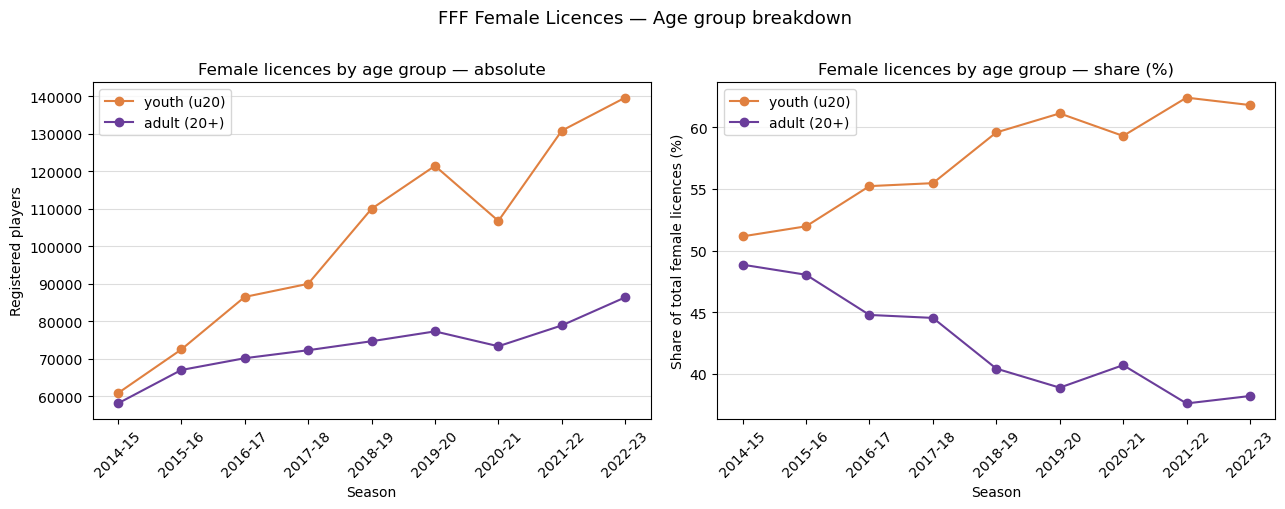

In [9]:
df_bands = df_french_data[
    (df_french_data["age_group"] == "native_band") &
    (df_french_data["gender"] == "female")
].copy()

# keep only seasons where all bands are present (v3: 2019 onwards has finer bands)
# for comparability, use the broader v2 band groupings across all years
YOUTH_BANDS  = ["1 à 4 ans", "5 à 9 ans", "10 à 14 ans", "15 à 19 ans"]
ADULT_BANDS  = ["20 à 29 ans", "30 à 44 ans", "45 à 59 ans",
                "60 à 74 ans", "75 ans et plus"]

# collapse to comparable groups across all schema versions
def assign_group(band):
    if any(band.startswith(b[:4]) for b in YOUTH_BANDS):
        return "youth (u20)"
    return "adult (20+)"

df_bands["broad_group"] = df_bands["age_threshold"].apply(assign_group)

df_broad = (df_bands.groupby(["season", "broad_group"])["registered_players"]
            .sum().reset_index())

# compute share within each season
df_broad["total_season"] = df_broad.groupby("season")["registered_players"].transform("sum")
df_broad["share_pct"] = df_broad["registered_players"] / df_broad["total_season"] * 100

seasons = sorted(df_broad["season"].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left panel: absolute licences by broad group
for group, color in [("youth (u20)", "#e08040"), ("adult (20+)", "#6a3d9a")]:
    sub = df_broad[df_broad["broad_group"] == group].sort_values("season")
    axes[0].plot(seasons, sub["registered_players"].values,
                 marker="o", color=color, label=group)

axes[0].set_title("Female licences by age group — absolute", fontsize=12)
axes[0].set_ylabel("Registered players")
axes[0].set_xlabel("Season")
axes[0].set_xticks(range(len(seasons)))
axes[0].set_xticklabels(seasons, rotation=45)
axes[0].legend(fontsize=10)
axes[0].yaxis.grid(True, color="#dddddd", linewidth=0.8)
axes[0].set_facecolor("white")

# right panel: share of total
for group, color in [("youth (u20)", "#e08040"), ("adult (20+)", "#6a3d9a")]:
    sub = df_broad[df_broad["broad_group"] == group].sort_values("season")
    axes[1].plot(seasons, sub["share_pct"].values,
                 marker="o", color=color, label=group)

axes[1].set_title("Female licences by age group — share (%)", fontsize=12)
axes[1].set_ylabel("Share of total female licences (%)")
axes[1].set_xlabel("Season")
axes[1].set_xticks(range(len(seasons)))
axes[1].set_xticklabels(seasons, rotation=45)
axes[1].legend(fontsize=10)
axes[1].yaxis.grid(True, color="#dddddd", linewidth=0.8)
axes[1].set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("FFF Female Licences — Age group breakdown", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Who is driving female growth in France?

The picture is unambiguous. Female football growth in France is a **youth phenomenon**.

In absolute terms, both age groups are growing, but youth licences (under 20) are growing far faster. From 2014-15 to 2022-23, youth licences nearly doubled from roughly 60,000 to 140,000, while adult licences grew from around 59,000 to 86,000 with a meaningful but much more modest increase.

The share panel makes the structural shift visible. In 2014-15, the split between youth and adult was almost exactly 50/50. By 2022-23, youth account for roughly 62% of all female licences. The composition of French women's football has shifted decisively towards younger players over less than a decade.

Two observations are worth noting. First, the COVID dip in 2020-21 hit youth licences harder than adult ones in absolute terms meaning youth dropped sharply while adult licences held relatively stable. This is consistent with the fact that youth football depends more on organised club activity, which was suspended, while adult participation may have been partially sustained through informal channels. Second, the post-COVID recovery was driven almost entirely by youth and adult licences recovered slowly and their share continued to fall after 2020-21.

This finding has implications for the cross-federation comparison. When comparing total female licence counts across countries, we are not comparing the same population: a federation with a younger age composition will count more licences per actual adult player. The age structure matters, and France's increasingly youth-heavy profile should be kept in mind when placing its numbers alongside Germany, Italy, or England.


### Age group breakdown - male licences

We apply the same analysis to male licences. Given that the total male series showed no clear growth trend and a noisy pattern around a slowly declining mean, the age breakdown may reveal whether different cohorts are moving in opposite directions — masking each other in the aggregate.


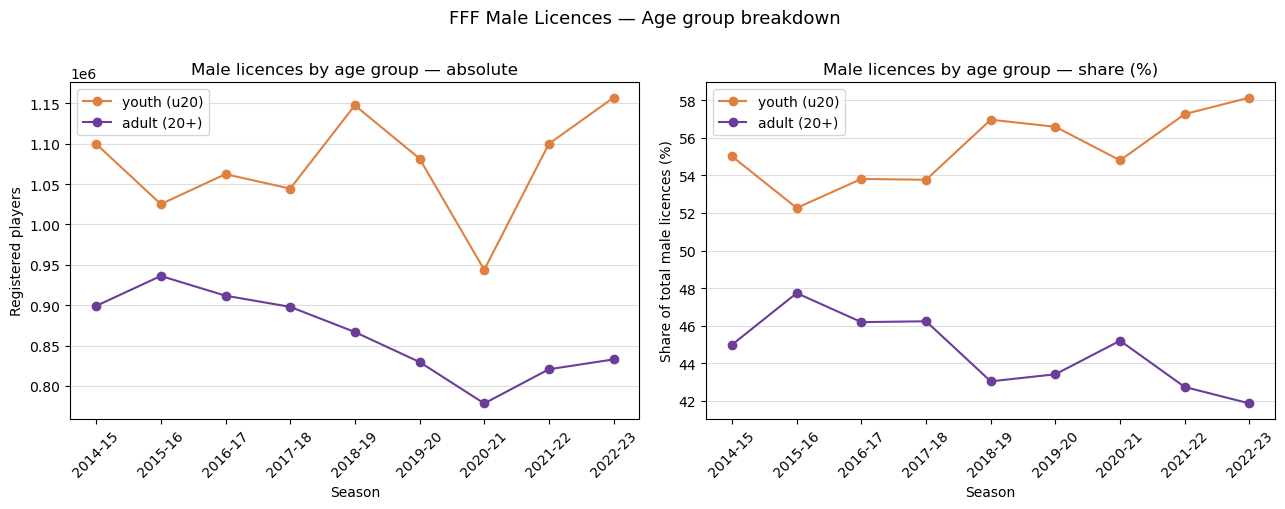

In [10]:
df_bands_m = df_french_data[
    (df_french_data["age_group"] == "native_band") &
    (df_french_data["gender"] == "male")
].copy()

df_bands_m["broad_group"] = df_bands_m["age_threshold"].apply(assign_group)

df_broad_m = (df_bands_m.groupby(["season", "broad_group"])["registered_players"]
              .sum().reset_index())

df_broad_m["total_season"] = df_broad_m.groupby("season")["registered_players"].transform("sum")
df_broad_m["share_pct"] = df_broad_m["registered_players"] / df_broad_m["total_season"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for group, color in [("youth (u20)", "#e08040"), ("adult (20+)", "#6a3d9a")]:
    sub = df_broad_m[df_broad_m["broad_group"] == group].sort_values("season")
    axes[0].plot(seasons, sub["registered_players"].values,
                 marker="o", color=color, label=group)
    axes[1].plot(seasons, sub["share_pct"].values,
                 marker="o", color=color, label=group)

for ax, title, ylabel in zip(
        axes,
        ["Male licences by age group — absolute",
         "Male licences by age group — share (%)"],
        ["Registered players", "Share of total male licences (%)"]):
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Season")
    ax.set_xticks(range(len(seasons)))
    ax.set_xticklabels(seasons, rotation=45)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("FFF Male Licences — Age group breakdown", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the male age breakdown reveals

The male series confirms and sharpens what the ITS model suggested: there is no single clean trend, but the age breakdown reveals a directional shift that the aggregate hides.

**Adult male licences are in structural decline.** From a peak of around 940,000 in 2015-16, adult licences fell steadily to roughly 830,000 by 2019-20, a loss of over 100,000 licences before COVID even arrived. Post-COVID, adult male licences have not recovered, stabilising around 835,000. Their share of total male licences has fallen from 45% in 2014-15 to 42% in 2022-23 with a consistent, slow erosion.

**Youth male licences are flat to slightly growing (but noisy).** Youth licences oscillate between roughly 1.03M and 1.15M with no clear direction, and are heavily affected by COVID (the 2020-21 drop was dramatic). By 2022-23 youth licences are at their series high, but given the noise in the series this is hard to interpret as a structural trend.

**The aggregate flatness is a composition effect.** Total male licences appear stable because youth volatility and adult decline roughly cancel each other out. This is an important methodological note: a flat aggregate can conceal opposing dynamics within it. The headline number (approximately 2 million male licences) masks a football landscape where adult male participation is quietly contracting while youth numbers fluctuate around a stable level.

Comparing this with the female picture produces a striking contrast: female football is growing at all age levels, with youth leading. Male football is stable in aggregate but declining among adults. These two trajectories, if sustained, will continue to narrow the gender gap in French football, driven not by female decline but by structural adult male attrition.